In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
  return 4*x**3 - 3*x**2 + 8*x + 1

In [3]:
f(2.0)

37.0

In [4]:
x_array = np.arange(-5 , 5 , 0.125)

In [5]:
x_array

array([-5.   , -4.875, -4.75 , -4.625, -4.5  , -4.375, -4.25 , -4.125,
       -4.   , -3.875, -3.75 , -3.625, -3.5  , -3.375, -3.25 , -3.125,
       -3.   , -2.875, -2.75 , -2.625, -2.5  , -2.375, -2.25 , -2.125,
       -2.   , -1.875, -1.75 , -1.625, -1.5  , -1.375, -1.25 , -1.125,
       -1.   , -0.875, -0.75 , -0.625, -0.5  , -0.375, -0.25 , -0.125,
        0.   ,  0.125,  0.25 ,  0.375,  0.5  ,  0.625,  0.75 ,  0.875,
        1.   ,  1.125,  1.25 ,  1.375,  1.5  ,  1.625,  1.75 ,  1.875,
        2.   ,  2.125,  2.25 ,  2.375,  2.5  ,  2.625,  2.75 ,  2.875,
        3.   ,  3.125,  3.25 ,  3.375,  3.5  ,  3.625,  3.75 ,  3.875,
        4.   ,  4.125,  4.25 ,  4.375,  4.5  ,  4.625,  4.75 ,  4.875])

In [6]:
y_array = f(x_array)

In [7]:
y_array

array([-6.14000000e+02, -5.72726562e+02, -5.33375000e+02, -4.95898438e+02,
       -4.60250000e+02, -4.26382812e+02, -3.94250000e+02, -3.63804688e+02,
       -3.35000000e+02, -3.07789062e+02, -2.82125000e+02, -2.57960938e+02,
       -2.35250000e+02, -2.13945312e+02, -1.94000000e+02, -1.75367188e+02,
       -1.58000000e+02, -1.41851562e+02, -1.26875000e+02, -1.13023438e+02,
       -1.00250000e+02, -8.85078125e+01, -7.77500000e+01, -6.79296875e+01,
       -5.90000000e+01, -5.09140625e+01, -4.36250000e+01, -3.70859375e+01,
       -3.12500000e+01, -2.60703125e+01, -2.15000000e+01, -1.74921875e+01,
       -1.40000000e+01, -1.09765625e+01, -8.37500000e+00, -6.14843750e+00,
       -4.25000000e+00, -2.63281250e+00, -1.25000000e+00, -5.46875000e-02,
        1.00000000e+00,  1.96093750e+00,  2.87500000e+00,  3.78906250e+00,
        4.75000000e+00,  5.80468750e+00,  7.00000000e+00,  8.38281250e+00,
        1.00000000e+01,  1.18984375e+01,  1.41250000e+01,  1.67265625e+01,
        1.97500000e+01,  

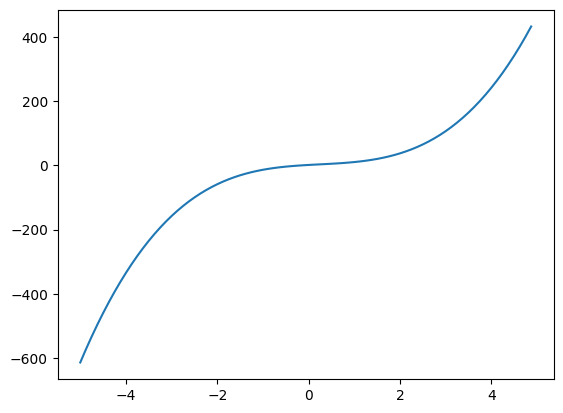

In [8]:
plt.plot(x_array , y_array)

In [9]:
h = 0.000000000000001
x = 0
(f(x+h) - f(x))/h

7.993605777301126

In [10]:
h = 0.00001
a = 2.0
b = -3.0
c = 4.0

d1 = a*b + c
a+= h
d2 = a*b + c
(d2-d1)/h

-3.000000000064062

In [35]:
class value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other , value) else value(other)
    out = value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other , value) else value(other)

    out = value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()




In [37]:
a = value(1.0)
b = a * 1

In [12]:
a = value(1.0 , label = "a")

In [13]:
b = value(2.0 , label="b")

In [14]:
c = a+b
c.label = "c"

In [15]:
a*b

Value(data=2.0)

In [16]:
c._prev

{Value(data=1.0), Value(data=2.0)}

In [17]:
c._op

'+'

In [18]:
d = c * a
d.label = "d"

In [19]:
m = value(-2.0 , label = "m")

In [20]:
L = m*d
L.label = "L"

In [21]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label , n.data , n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

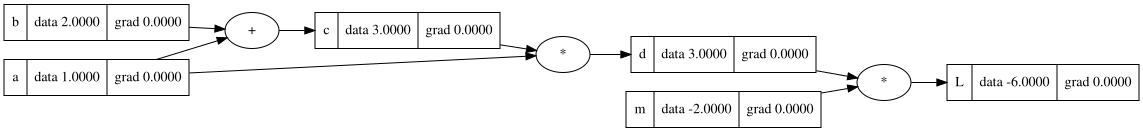

In [22]:
draw_dot(L)

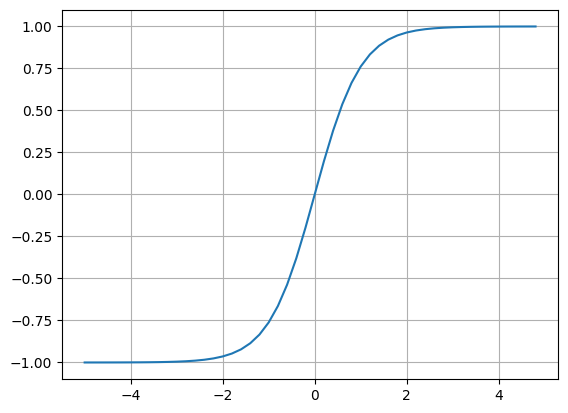

In [23]:
plt.plot(np.arange(-5 , 5 , 0.2) , np.tanh(np.arange(-5 , 5 , 0.2))); plt.grid()

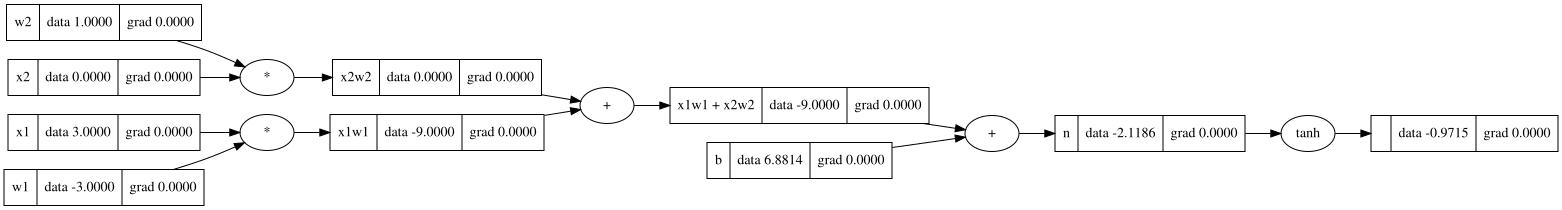

In [24]:
x1 = value(3.0 , label = "x1")
x2 = value(0.0 , label = "x2")
w1 = value(-3.0 , label = "w1")
w2 = value(1.0 , label = "w2")
b = value(6.8813735870195432 , label = "b")
x1w1 = x1*w1; x1w1.label = "x1w1"
x2w2 = x2*w2; x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1 + x2w2"
n = x1w1x2w2 + b; n.label = "n"
out = n.tanh()
draw_dot(out)

In [25]:
L.grad = 0
out.grad = 1
out.label = "out"

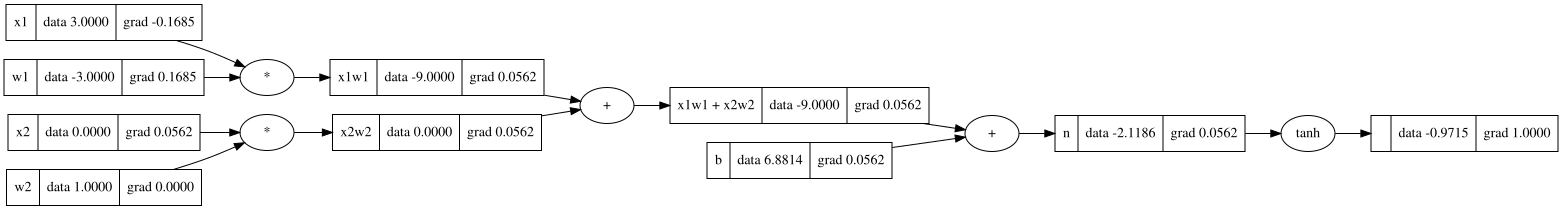

In [ ]:
draw_dot(out)

In [ ]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(out)
topo

for node in reversed(topo):
  node._backward()

In [ ]:
out.grad = 1

In [ ]:
out._backward()

In [ ]:
n._backward()

In [ ]:
x1w1x2w2._backward()

In [ ]:
x1w1._backward()
x2w2._backward()

In [ ]:
n.grad = 1- (out.data**2)

In [ ]:
b = n.grad
x1w1x2w2.grad = n.grad

In [ ]:
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

In [ ]:
x2.grad = w2.data * x1w1x2w2.grad
x1.grad = w1.data * x1w1x2w2.grad

In [ ]:
w1.grad = x1.data * x1w1x2w2.grad
w2.grad = x2.data * x1w1x2w2.grad

In [ ]:
out.backward()